In [1]:
import os
import numpy as np
import pandas as pd
import scipy

from IPython.display import display
from tqdm.auto import tqdm

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

from src.styles import *
from src.visualization import *

from src.data_utils import remove_duplicate_texts, load_vader_words, load_gervader_words
from src.preprocessing import run_preprocessing_loop
from src.training import *
from src.model_utils import *
from src.evaluation import *


In [2]:
##########
# Data Import
##########

# Variable Definition
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"
stopword_path = "data/stopwords_custom.json"

# Import data to pandas dataframe
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

# Remove duplicate Requests
df_reviews = remove_duplicate_texts(df_reviews, text_col="review")


##########
# Stopword Definition
##########

# Import Sentiment Stopwords based on threshold
sia_en = SentimentIntensityAnalyzer()
de_thres = 2
en_thres = 1.5

vader_words_en = load_vader_words(sia_en, en_thres)
gervader_words_de = load_gervader_words("GerVADER/GERVaderLexicon.txt", de_thres)

# Build Basis-Dictionary
dict_stopw_default = {
    "iter_0": {
        "de_nltk_common": stopwords.words("german"),
        "de_vader_topic_only":gervader_words_de,
        "en_nltk_common": stopwords.words("english"),
        "en_vader_topic_only":vader_words_en,
        
    },
    "iter_1": {
        "de_custom_common": [],
        "de_custom_topic_only": [],
        "en_custom_common": [],
        "en_custom_topic_only": []
    }
}


=== Duplicate Removal ===
Before: 2000 rows
After:  1749 rows
Removed: 251 duplicates


In [3]:
##########
# Data PreProcessing
##########

top_n = 30       # Number of top tokens to display
n_process = 1    # Number of parallel processes (performance tuning)


# Run interactive preprocessing pipeline:
# - Loads or initializes stopword configuration (JSON)
# - Applies iterative stopword refinement (user-guided)
# - Cleans and tokenizes text for both topic modeling and sentiment analysis
# - Displays top token comparisons for validation
# - Repeats until user confirms final stopw

data_topic, data_sentiment, dict_stopw = run_preprocessing_loop(
    df_reviews=df_reviews,
    stopword_path=stopword_path,
    dict_stopw_default=dict_stopw_default,
    top_n=top_n,
    n_process=n_process
)


Stopword file found -> loading

Cleaning Data - Topic Modeling


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 83.16it/s]



Cleaning Data - Sentiment Analysis


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 84.60it/s]



Please review the top tokens and optionally extend them under 'iter_9' in data/stopwords_custom.json.
1 = JSON updated manually, start next iteration
2 = finished, continue with topic modeling


Selection:  2



Final stopwords applied. Proceeding to topic modeling.


In [4]:
############
# Create Vectors with BoW & TF-IDF
############

# Separate Pipelines: Topic Modeling vs. Sentiment
print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)

Creating Vectors - Topic Modeling
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features

Creating Vectors - Sentiment Analysis
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features


In [5]:
############
# LDA/BoW - Model Tuning (en|de)
############

# Perform LDA parameter tuning per language using Grid Search.
# Explores multiple configurations to identify optimal topic models
# for each language-specific dataset.

# -----------------------------
# CONFIGURATION
# -----------------------------

# Full parameter grid (production mode - slow but thorough)
lda_config_prod = {
    "topic_grid": [5, 10, 15, 20],   # number of topics to test
    "alpha_grid": [0.01, 0.1],       # document-topic prior (sparsity control)
    "eta_grid": [0.01, 0.1],         # topic-word prior
    "max_iter_grid": [10, 20],       # number of training iterations
    "random_states": [1, 2, 3],      # multiple runs for robustness
    "learning_method": "batch",      # batch learning for stable convergence
}

# Minimal parameter grid (test mode - fast execution)
lda_config_test = {
    "topic_grid": [10],          # single topic value
    "alpha_grid": [0.1],         # single prior
    "eta_grid": [0.1],           # single prior
    "max_iter_grid": [10],       # minimal iterations
    "random_states": [1],        # single seed
    "learning_method": "batch",
}

# -----------------------------
# SWITCH BETWEEN MODES
# -----------------------------

TEST_MODE = True  # set to False for full tuning

lda_config = lda_config_test if TEST_MODE else lda_config_prod


# -----------------------------
# RUN TUNING
# -----------------------------

# Dictionary to store tuning results separately for each language
lda_tuning_results_by_lang = {}

# Iterate over language-specific BOW vectorized datasets
for lang, data in vectors_topic["bow_by_lang"].items():

    # Apply selected configuration (test or production)
    lda_tuning_results_by_lang[lang] = tune_lda_models(
        data=data,
        topic_grid=lda_config["topic_grid"],
        alpha_grid=lda_config["alpha_grid"],
        eta_grid=lda_config["eta_grid"],
        max_iter_grid=lda_config["max_iter_grid"],
        random_states=lda_config["random_states"],
        learning_method=lda_config["learning_method"],
        lang=lang
    )

LDA Tuning (en): 100%|████████████████████| 1/1 [00:05<00:00,  5.20s/it, k=10, iter=10, coh=0.69, std=0.000, perp=1737]


In [18]:
############
# LDA/BoW - Tuning Validation (en|de)
############

# Define evaluation configuration for LDA tuning results.
# Each metric includes:
# - col: column name in the tuning results
# - weight: contribution to overall score
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds for scoring normalization
# - format: display formatting
lda_tuning_config = [
    {"col": "coherence",               "weight": 0.30, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.2f}"},
    {"col": "coherence_std",           "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    {"col": "perplexity",              "weight": 0.20, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "largest_topic_share",     "weight": 0.15, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "avg_word_overlap",        "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LDA tuning results per language:
# - Computes weighted scores based on defined metrics
# - Ranks models by overall performance
# - Displays top configurations with formatted styling
lda_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lda_tuning_results_by_lang,
    tuning_config=lda_tuning_config,
    title="LDA/BoW Tuning",
    head_rows=15,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide non-relevant or heavy columns for display clarity
        "topic_words", "topic_terms", "doc_topic_matrix", "model",
        "max_word_overlap", "largest_topic_share_std", "perplexity_std"
    ]
)



=== LDA/BoW Tuning (de) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
0,10,0.100000,0.100000,10,2.14,0.00,1508.4191,0.1856,0.0094,1,0.3000



=== LDA/BoW Tuning (en) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
0,10,0.100000,0.100000,10,0.69,0.00,1736.8539,0.1301,0.1037,1,0.3000


In [7]:
############
# LSA/TF-IDF - Model Tuning (en|de)
############

# Perform parameter tuning for LSA (Latent Semantic Analysis)
# on TF-IDF features, evaluated separately for each language.
# The goal is to identify optimal semantic dimensionality and
# stable decomposition settings.


# Dictionary to store tuning results per language (e.g. 'en', 'de')
lsa_tuning_results_by_lang = {}

# Iterate over language-specific TF-IDF vectorized datasets
for lang, data in vectors_topic["tfidf_by_lang"].items():

    # Perform LSA model tuning using different hyperparameter combinations:
    # - topic_grid: number of latent semantic components (topics)
    #   higher values → finer topic separation, but harder interpretation
    # - n_iter_grid: number of SVD iterations
    #   more iterations → better convergence and stability, but slower runtime
    # - random_state: fixed seed for reproducibility
    # - lang: used for logging or progress tracking
    lsa_tuning_results_by_lang[lang] = tune_lsa_models(
        data=data,
        topic_grid=[10, 20, 30, 40],
        n_iter_grid=[10, 20, 30],
        random_state=42,
        lang=lang
    )

LSA Tuning (en): 100%|██████████████████████████████| 12/12 [00:48<00:00,  4.03s/it, k=40, iter=30, coh=0.48, var=0.18]


In [19]:
############
# LSA/TF-IDF - Tuning Validation (en|de)
############

# Define evaluation configuration for LSA tuning results.
# Each metric contributes to the final score using a weighted scheme:
# - col: metric name in the tuning results DataFrame
# - weight: importance of the metric in overall ranking
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds used for normalization/scoring
# - format: display formatting for readability
lsa_tuning_config = [
    {"col": "avg_word_overlap",     "weight": 0.16, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "coherence",            "weight": 0.42, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "explained_variance",   "weight": 0.17, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "largest_topic_share",  "weight": 0.25, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LSA tuning results for each language:
# - Computes normalized and weighted scores based on the configuration
# - Ranks model configurations by overall performance
# - Displays the top results with formatted styling for comparison
lsa_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lsa_tuning_results_by_lang,
    tuning_config=lsa_tuning_config,
    title="LSA/TF-IDF Tuning",
    head_rows=10,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide large or non-essential columns to improve readability
        "topic_words", "topic_terms", "doc_topic_matrix", "model"
    ]
)


=== LSA/TF-IDF Tuning (de) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
0,10,10,2.6949,0.5167,0.1293,0.0131,0.111111,0.5848
2,10,30,2.6951,0.5234,0.1293,0.0131,0.111111,0.5800
1,10,20,2.6951,0.5234,0.1293,0.0131,0.111111,0.5800
11,40,30,2.0006,0.1816,0.2574,0.0449,0.538462,0.5120
10,40,20,1.9663,0.1856,0.2573,0.0459,0.538462,0.4870
9,40,10,1.9269,0.1829,0.2569,0.0498,0.538462,0.4530
7,30,20,2.0233,0.2256,0.2196,0.0509,0.538462,0.4197
8,30,30,2.0135,0.2296,0.2196,0.0509,0.538462,0.4117
5,20,30,2.1697,0.3084,0.1780,0.0482,0.538462,0.3922
4,20,20,2.1754,0.3084,0.1780,0.0496,0.538462,0.3899



=== LSA/TF-IDF Tuning (en) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
10,40,20,0.4919,0.3223,0.1802,0.0968,0.666667,0.9960
11,40,30,0.4847,0.3243,0.1802,0.0979,0.666667,0.9721
9,40,10,0.4762,0.3183,0.1797,0.0964,0.666667,0.9537
7,30,20,0.4421,0.3824,0.1460,0.1293,0.666667,0.7111
8,30,30,0.4401,0.3834,0.1460,0.1299,0.666667,0.7039
6,30,10,0.4247,0.3914,0.1458,0.1288,0.666667,0.6529
3,20,10,0.4128,0.4474,0.1072,0.1696,0.666667,0.4654
4,20,20,0.4076,0.4505,0.1073,0.1698,0.666667,0.4476
5,20,30,0.4069,0.4505,0.1073,0.1694,0.666667,0.4460
2,10,30,0.3526,0.5956,0.0616,0.2327,0.666667,0.0199


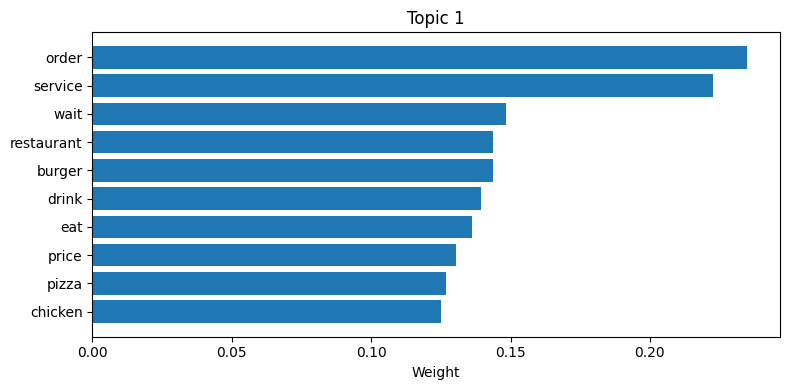

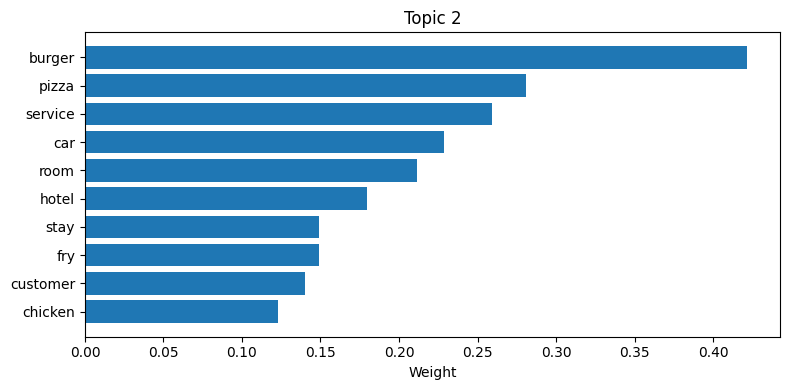

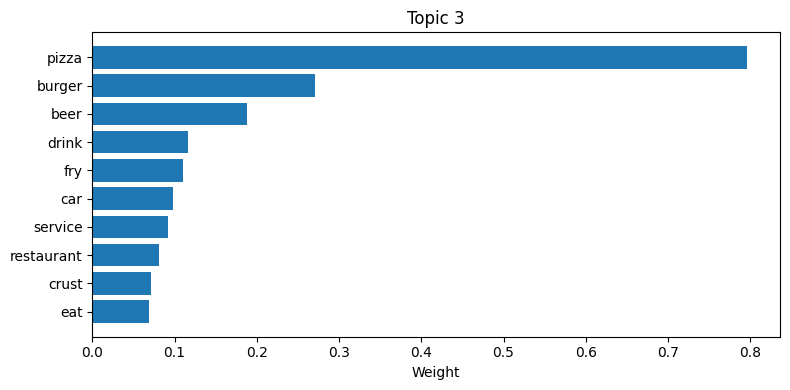

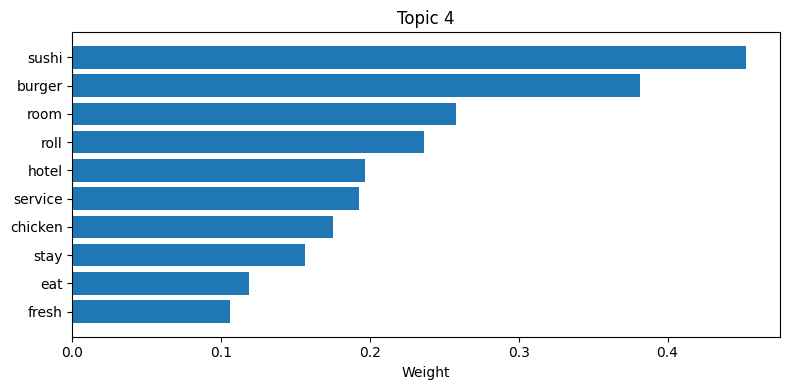

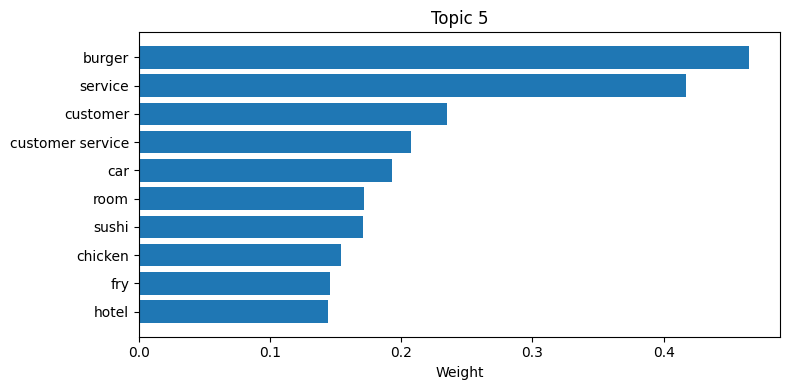

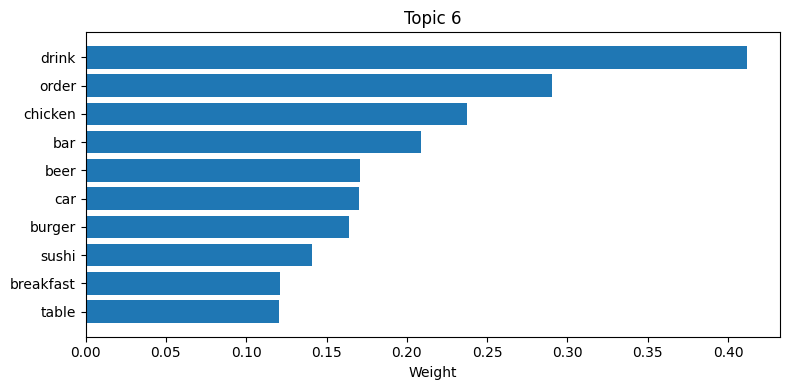

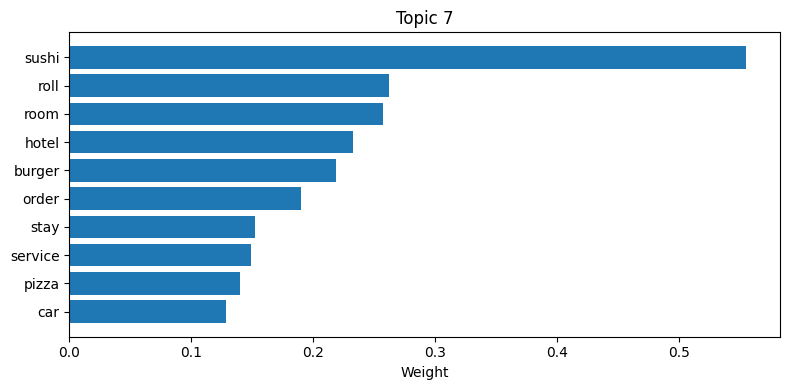

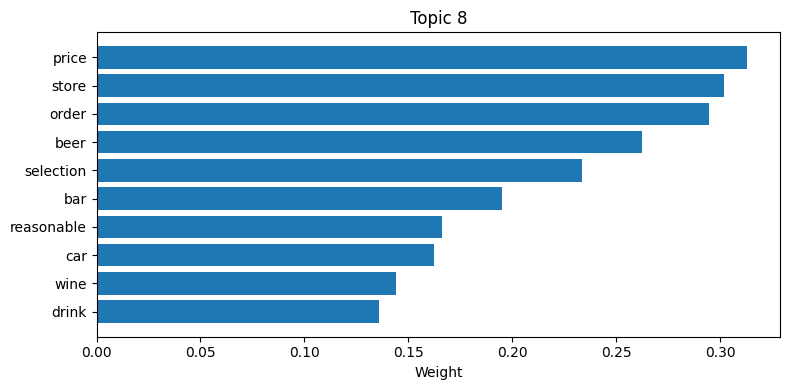

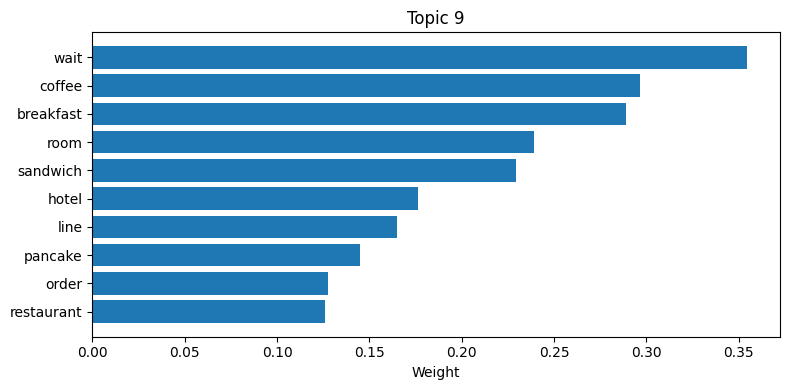

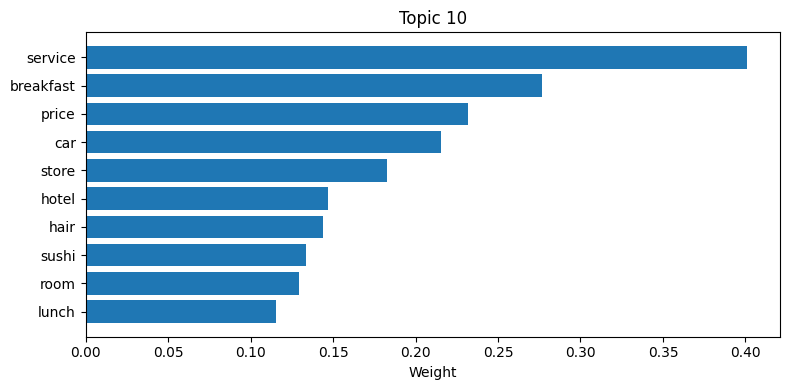

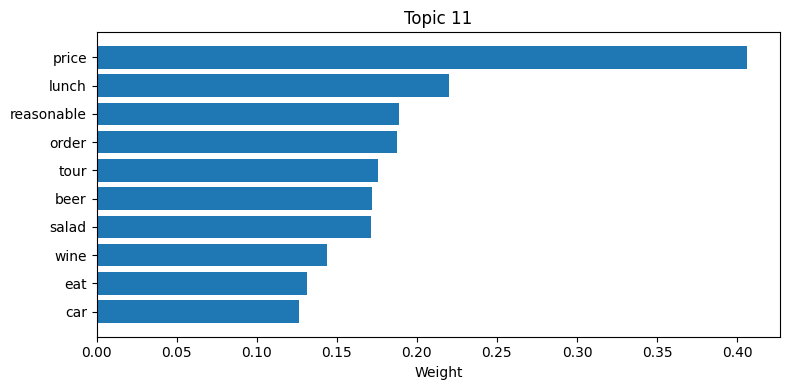

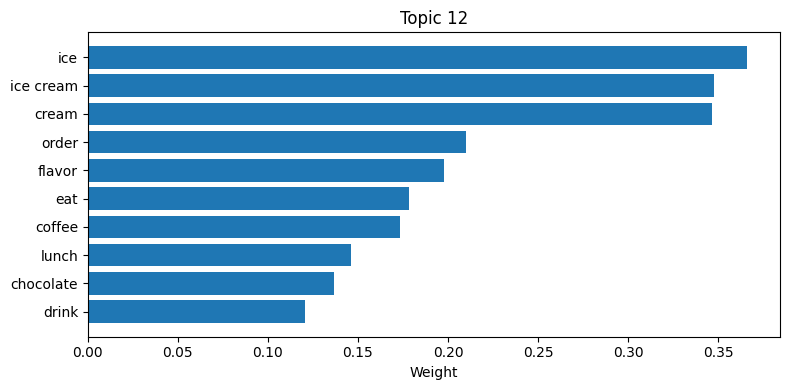

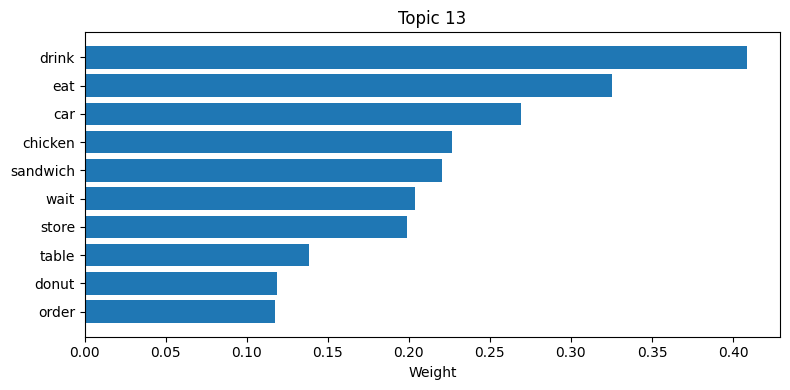

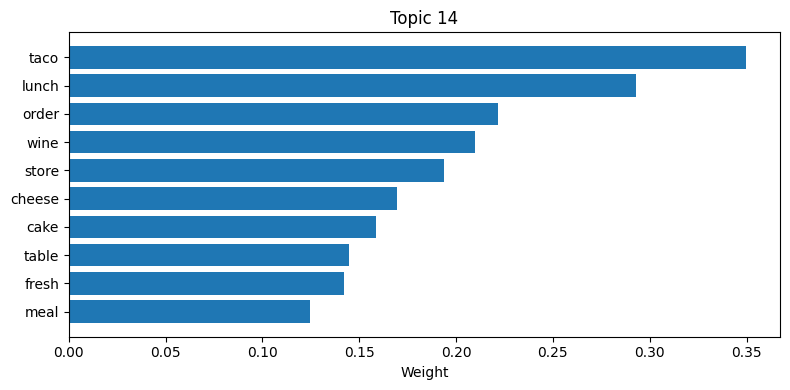

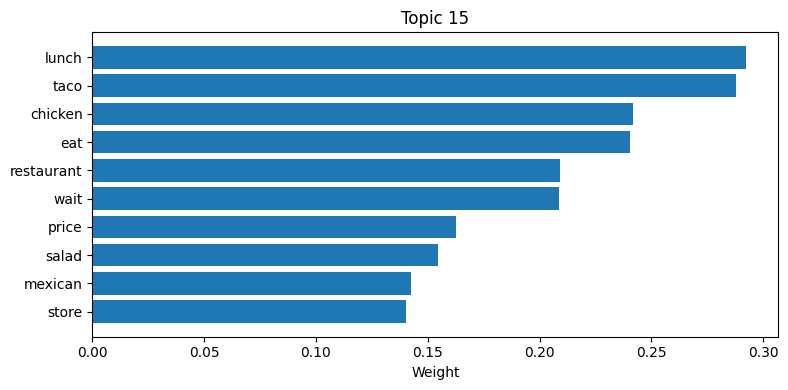

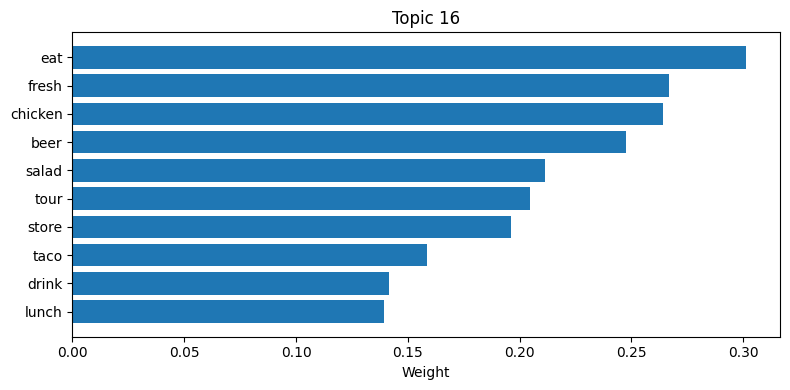

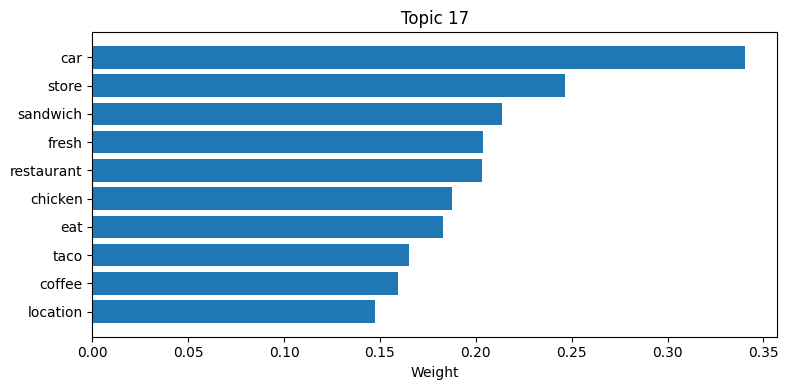

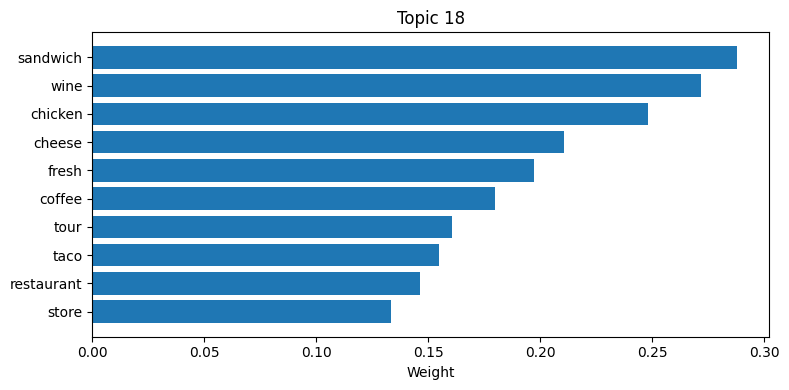

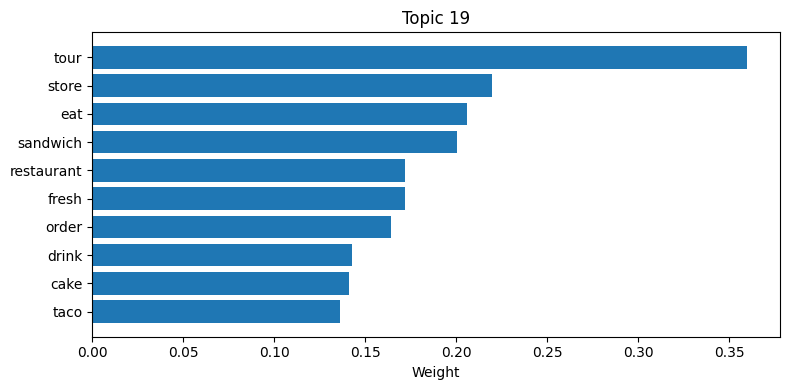

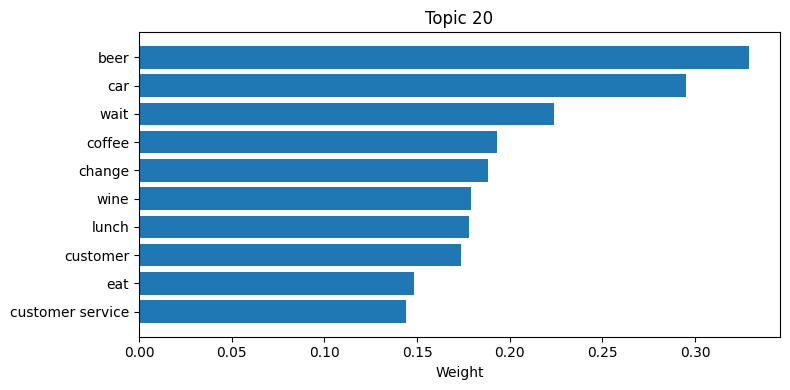

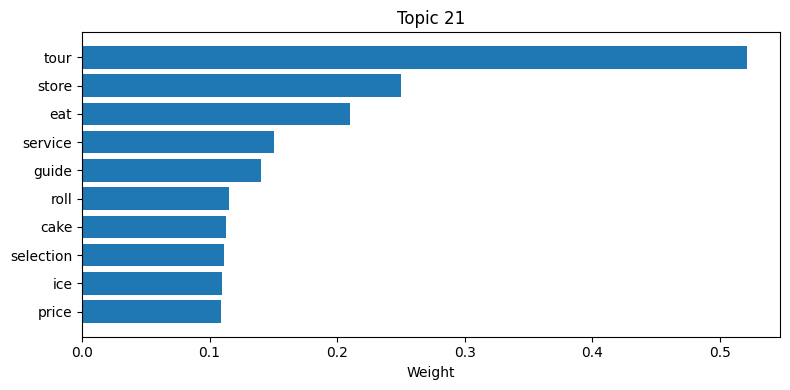

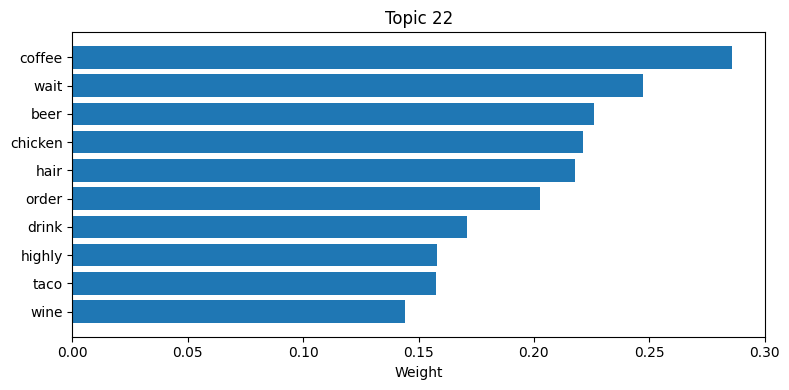

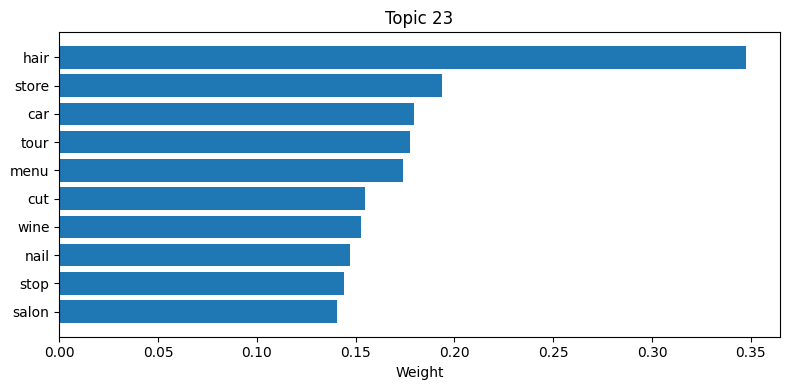

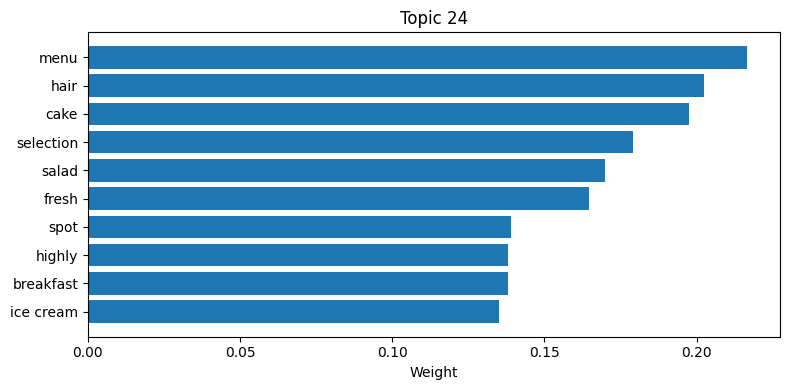

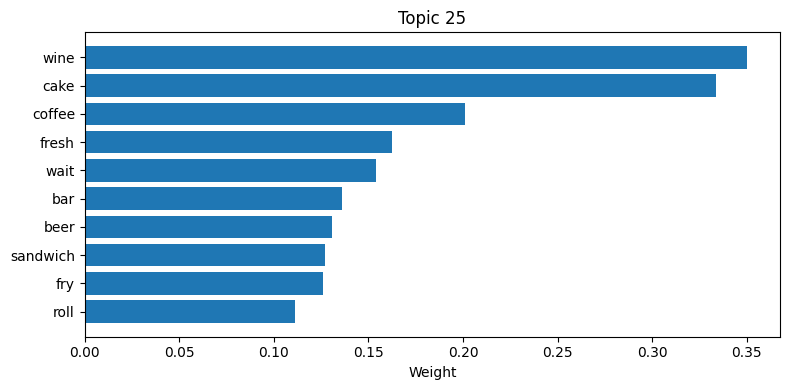

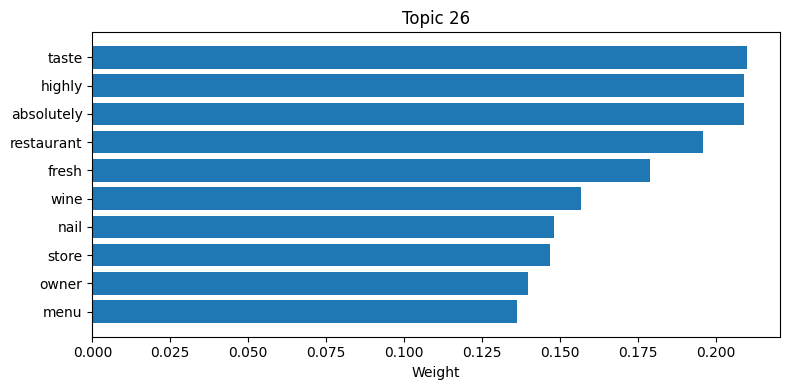

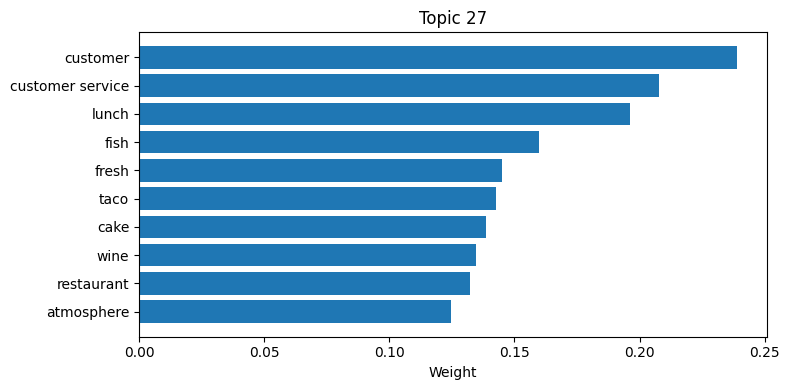

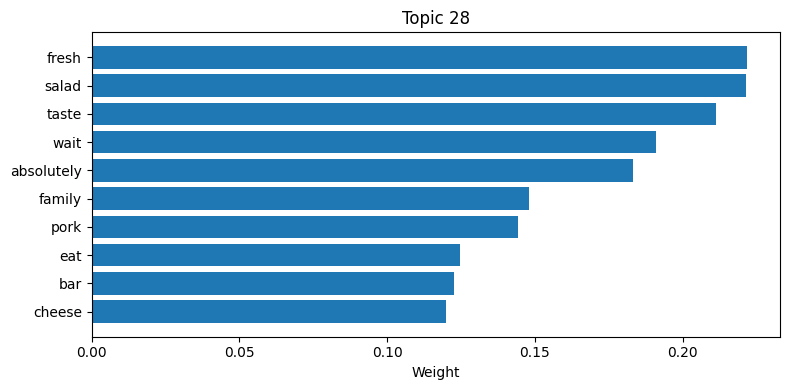

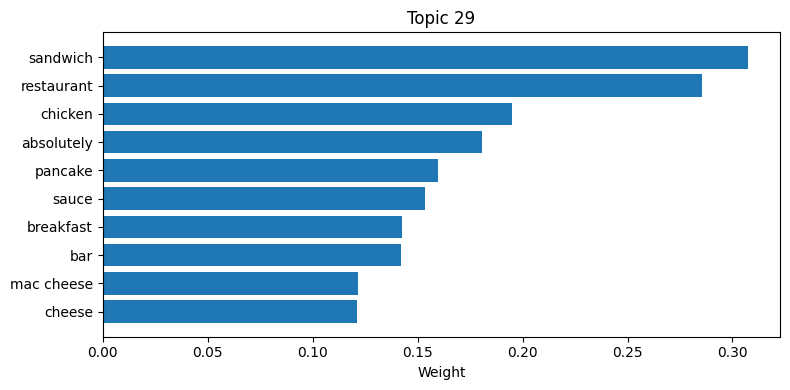

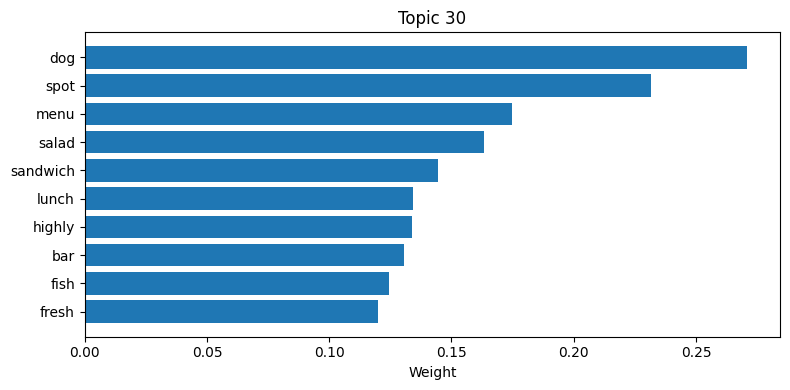

In [22]:
# Zeigt die wichtigsten Wörter je Topic
# Erkenntnis:
# - Sind Topics semantisch klar/interpretiertbar?
# - Gibt es generische oder unscharfe Topics?
# - Sind Topics redundant oder klar getrennt?
best_row = lsa_tuning_interpreted_by_lang["en"].iloc[3]
plot_multiple_topics(best_row)

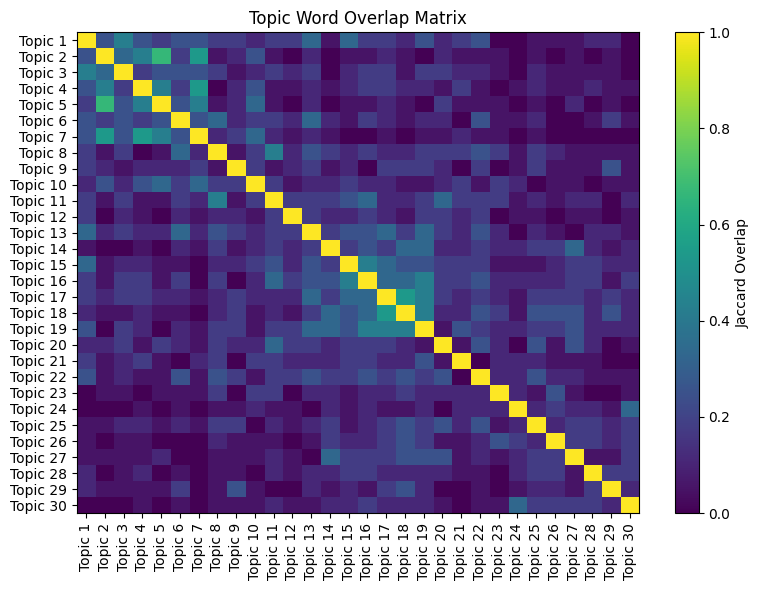

In [23]:
# Zeigt Überschneidungen der Top-Wörter zwischen Topics
# Erkenntnis:
# - Gibt es redundante/ähnliche Topics?
# - Wurden zu viele Topics erzeugt?
# - Wie gut ist die Topic-Separation?
plot_topic_overlap_matrix(best_row)

In [20]:
############
# LSA/TF-IDF - TopWort Vergleich der Top3 Scores (en|de)
############

display_top_topic_models(
    tuning_interpreted_by_lang=lsa_tuning_interpreted_by_lang,
    model_name="LSA/TF-IDF",
    top_k=3
)

display_top_topic_models(
    tuning_interpreted_by_lang=lda_tuning_interpreted_by_lang,
    model_name="LDA/BoW",
    top_k=3
)


=== Top 3 LSA/TF-IDF Modelle (de) ===

--- Rang 1 | Index 0 | Score: 0.5848 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.4%),persönlich (14.9%)
1,kosten (9.7%),erwartungshorizonte (16.4%),dokumentiert geschlachtet (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide schlachtbetrieb (22.1%),meldung (11.9%),stadt (16.6%),gymnasium (13.0%)
2,umweltinformation (9.4%),fach (16.3%),behördlich überwachung (10.1%),unternehmen (11.4%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide (22.1%),unterweisung (10.3%),straße (9.6%),deutsch (11.8%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet tier (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.0%),probeunterricht (11.6%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.7%),stadt münchen (7.2%),gebrauch (9.9%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),anordnung (6.2%),gymnasium persönlich (8.6%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),unterwiesen (7.8%),feuerwehr (6.1%),persönlich gebrauch (8.6%)
7,behandeln (9.0%),fach englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),verdacht impfnebenwirkung (7.8%),bewertung (5.9%),schule (7.6%)
8,umweltinformation bund (8.9%),englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),recherche abbruch (8.8%),verfolgen (8.0%),metzgerei (2.5%),impfnebenwirkung (7.8%),hiermit (5.9%),feuerwehr (7.4%)
9,bund uig (8.9%),fach physik (2.5%),differenzieren tierart (9.6%),menge (8.0%),verfahrensstand bebauungsplanverfahr (8.8%),schule (7.7%),aschaffenburg (2.5%),verpﬂichten (7.8%),gutachten (5.9%),schwärzen (6.7%)



--- Rang 2 | Index 2 | Score: 0.5800 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.2%),persönlich (15.4%)
1,kosten (9.7%),erwartungshorizonte (16.4%),dokumentiert geschlachtet (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide (22.1%),meldung (11.9%),stadt (16.6%),gymnasium (12.6%)
2,umweltinformation (9.4%),fach (16.3%),behördlich überwachung (10.1%),unternehmen (11.4%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide schlachtbetrieb (22.1%),unterweisung (10.3%),straße (9.7%),probeunterricht (11.3%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet tier (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.1%),deutsch (11.2%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.7%),stadt münchen (7.2%),gebrauch (9.6%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),anordnung (6.3%),persönlich gebrauch (8.4%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),ärztinn (7.8%),feuerwehr (6.2%),gymnasium persönlich (8.4%)
7,behandeln (9.0%),fach englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),verdacht impfnebenwirkung (7.8%),hiermit (5.9%),feuerwehr (8.3%)
8,datenschutzgesetz umweltinformation (8.9%),englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),abbruch benötigen (8.8%),verfolgen (8.0%),metzgerei (2.5%),unterwiesen (7.8%),bewertung (5.9%),schule (7.6%)
9,uig verbesserung (8.9%),fach biologie (2.5%),differenzieren tierart (9.6%),menge (8.0%),dazugehörig bebauungsplan (8.8%),schule (7.7%),aschaffenburg (2.5%),unerwünscht arzneimittelwirkung (7.8%),intern (5.8%),schwärzen (7.3%)



--- Rang 3 | Index 1 | Score: 0.5800 | Topics: 10 ---


...

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,...,Topic 31,Topic 32,Topic 33,Topic 34,Topic 35,Topic 36,Topic 37,Topic 38,Topic 39,Topic 40
0,order (15.1%),burger (19.7%),pizza (42.1%),sushi (19.9%),burger (20.2%),drink (20.2%),sushi (24.3%),price (14.2%),wait (16.5%),service (20.3%),...,cake (14.4%),coffee (14.5%),steak (17.2%),change (12.7%),line (14.2%),quick (14.1%),owner (14.6%),change (12.6%),thai (12.3%),cake (11.8%)
1,service (14.4%),pizza (13.1%),burger (14.3%),burger (16.8%),service (18.1%),order (14.3%),roll (11.5%),store (13.7%),coffee (13.8%),breakfast (14.0%),...,stop (12.3%),fresh (12.1%),return (12.9%),flavor (12.3%),change (12.1%),taste (13.6%),location (12.0%),menu (12.5%),authentic (11.8%),hair (11.2%)
2,wait (9.6%),service (12.1%),beer (9.9%),room (11.3%),customer (10.2%),chicken (11.6%),room (11.3%),order (13.3%),breakfast (13.4%),price (11.7%),...,drink (10.6%),breakfast (10.5%),change (10.7%),table (11.8%),highly (11.2%),fry (11.1%),indian (10.5%),nail (11.2%),dog (11.6%),shrimp (10.5%)
3,restaurant (9.3%),car (10.7%),drink (6.1%),roll (10.4%),customer service (9.0%),bar (10.3%),hotel (10.2%),beer (11.9%),room (11.1%),car (10.9%),...,family (10.5%),change (9.9%),dog (9.7%),dog (10.5%),owner (10.6%),steak (10.9%),menu (9.9%),week (10.7%),wine (10.2%),atmosphere (10.4%)
4,burger (9.3%),room (9.9%),fry (5.8%),hotel (8.6%),car (8.4%),beer (8.4%),burger (9.6%),selection (10.6%),sandwich (10.7%),store (9.2%),...,restaurant (10.5%),atmosphere (9.4%),taste (9.3%),wait (9.9%),different (10.3%),roll (9.7%),meal (9.2%),hair (9.6%),location (9.5%),fresh (10.4%)
5,drink (9.0%),hotel (8.4%),car (5.2%),service (8.5%),room (7.5%),car (8.4%),order (8.3%),bar (8.8%),hotel (8.2%),hotel (7.4%),...,meal (10.0%),order (9.0%),cook (8.5%),taste (9.9%),nail (10.0%),highly (8.3%),stop (9.1%),quick (9.6%),server (9.4%),star (10.1%)
6,eat (8.8%),stay (7.0%),service (4.9%),chicken (7.7%),sushi (7.4%),burger (8.1%),stay (6.7%),reasonable (7.5%),line (7.7%),hair (7.3%),...,guy (9.7%),thai (9.0%),salad (8.3%),beer (8.5%),cafe (8.7%),wait (8.3%),flavor (8.9%),roll (9.1%),sandwich (9.1%),home (9.9%)
7,price (8.4%),fry (7.0%),restaurant (4.3%),stay (6.9%),chicken (6.7%),sushi (6.9%),service (6.5%),car (7.3%),pancake (6.8%),sushi (6.8%),...,local (7.4%),soup (8.9%),soup (8.1%),fry (8.3%),music (8.1%),cheese (8.1%),atmosphere (8.8%),return (8.9%),customer (8.8%),restaurant (9.4%)
8,pizza (8.2%),customer (6.5%),crust (3.7%),eat (5.2%),fry (6.3%),breakfast (5.9%),pizza (6.1%),wine (6.5%),order (5.9%),room (6.5%),...,change (7.4%),store (8.7%),hot (7.8%),order (8.1%),sandwich (7.5%),change (7.9%),kid (8.5%),cake (7.9%),potato (8.7%),absolutely (8.2%)
9,chicken (8.1%),chicken (5.7%),eat (3.6%),fresh (4.7%),hotel (6.3%),table (5.9%),car (5.6%),drink (6.1%),restaurant (5.9%),eat (5.8%),...,customer (7.1%),customer (8.1%),customer (7.4%),cheese (8.0%),taste (7.2%),hair (7.8%),absolutely (8.4%),dog (7.8%),seafood (8.5%),cut (8.1%)



=== Top 3 LDA/BoW Modelle (de) ===

--- Rang 1 | Index 0 | Score: 0.3000 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,arzt (18.9%),münchen (30.7%),straße (13.4%),verfolgen (14.5%),verbraucherinformation (15.9%),studie (14.4%),fördermeng (14.7%),maßnahme (19.1%),straße (12.7%),entscheidung (13.5%)
1,meldung (12.3%),haus (11.9%),lehrkraft (12.7%),parkplatz (12.6%),kosten (11.3%),einrichtung (13.1%),genehmigt (12.6%),einsatz (11.4%),schlachthof (10.9%),schwärzen (13.4%)
2,medizinisch (11.0%),verfügbar (9.1%),gehweg (11.3%),nürnberg (12.0%),umweltinformation (11.1%),nierenschäde (12.8%),unternehmen (12.6%),stadt (10.3%),aufgabe (10.4%),verfügung (11.0%)
3,verdacht (9.6%),kosten (8.8%),unterbringung (10.3%),verfahrensstand (9.3%),gebühr (10.1%),signifikant (10.4%),genehmigt fördermeng (9.8%),konkret (10.3%),tier (10.2%),waffenschein (10.2%)
4,unerwünscht (9.3%),zpo (7.9%),anordnung (9.9%),baubeginn (9.3%),geringfügig (9.0%),bericht (10.4%),kalenderjahr (9.2%),biber (8.8%),überwachung (9.8%),mitglied (10.1%)
5,unterweisung (9.3%),freistaat (7.7%),prüfung (9.9%),bebauungsplanverfahr (8.7%),datenschutzgesetz (8.8%),akut (8.8%),genehmigung (9.0%),kosten (8.4%),dokumentiert (9.4%),digital (8.7%)
6,hintergrund (8.8%),einzeln (6.1%),münchen (8.3%),gemarkung (8.7%),geringfügig gebühr (8.6%),verschieden (8.3%),wasser (8.2%),beantworten (8.2%),behördlich (9.3%),antragsteller (8.6%)
7,unterwiesen (7.0%),bestehen (6.0%),bundesland (8.2%),kosten (8.6%),kosten geringfügig (8.6%),steuer (7.3%),kommunal (8.1%),politisch (8.0%),geschlachtet tier (9.1%),kommunikation (8.1%)
8,ärztinn (7.0%),erheblich (6.0%),landratsamt (8.1%),recherche (8.3%),behandeln (8.3%),impfstoff (7.3%),menge (8.0%),detailliert (7.9%),geschlachtet (9.1%),führen (8.1%)
9,verpﬂichten (7.0%),vollständig (5.8%),geben (8.0%),aktueller verfahrensstand (8.0%),uig (8.3%),international (7.2%),entrichten (7.8%),bereich (7.7%),fach (9.1%),persönlich (8.1%)



=== Top 3 LDA/BoW Modelle (en) ===

--- Rang 1 | Index 0 | Score: 0.3000 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,hair (19.7%),restaurant (19.4%),order (19.9%),pizza (18.2%),order (21.8%),chicken (17.8%),burger (17.7%),room (22.1%),service (25.4%),tour (23.6%)
1,salad (13.7%),breakfast (16.7%),drink (16.5%),bar (18.0%),burger (14.9%),order (11.8%),price (12.7%),hotel (14.2%),car (16.0%),guest (12.7%)
2,chicken (12.4%),salad (9.3%),taco (14.0%),service (13.8%),wait (12.6%),table (10.9%),service (12.4%),stay (10.4%),price (11.8%),room (9.8%)
3,service (8.6%),wait (9.2%),restaurant (8.6%),order (11.6%),table (9.7%),service (9.9%),cheese (11.6%),wait (8.9%),customer (10.8%),stop (9.4%)
4,lunch (8.4%),home (9.1%),sauce (7.2%),beer (9.3%),restaurant (7.9%),roll (9.4%),beer (10.8%),bar (8.6%),restaurant (7.5%),nail (8.8%)
5,flavor (8.3%),service (9.1%),pork (7.1%),bartender (7.6%),service (7.8%),thai (8.5%),eat (7.7%),check (7.7%),customer service (5.9%),week (8.5%)
6,ice (7.6%),sandwich (7.1%),service (6.8%),sport (6.4%),location (7.0%),soup (8.4%),order (7.5%),menu (7.6%),sale (5.7%),chocolate (7.2%)
7,cut (7.2%),menu (6.7%),menu (6.7%),sit (5.1%),pizza (6.5%),server (8.3%),pizza (6.7%),hear (7.4%),sushi (5.7%),star (6.7%)
8,taste (7.2%),type (6.7%),bar (6.6%),crab (5.1%),fry (6.2%),eat (7.7%),fry (6.5%),order (6.6%),pay (5.7%),car (6.7%)
9,cheese (6.8%),coffee (6.7%),shrimp (6.6%),offer (4.8%),menu (5.4%),wait (7.4%),wine (6.4%),table (6.5%),family (5.6%),wedding (6.5%)


In [21]:
############
# FINAL TOPIC + SENTIMENT PIPELINE
# Separate Vector Spaces:
# - Topic Modeling: captures semantic structure of documents
# - Sentiment Analysis: captures emotional polarity independently
############

# 1. Manually Select Final Models
# Select best-performing configurations based on prior evaluation.
# Each selection defines:
# - modeling approach (LDA or LSA)
# - chosen parameter configuration (row)
# - corresponding vector spaces for topic and sentiment analysis
selected_models = {

    "de": {
        "method": "lda",
        "title": "LDA BoW (de)",

        # Top-ranked model from LDA tuning results
        "row": lda_tuning_interpreted_by_lang["de"].iloc[0],

        # Use Bag-of-Words representation for both tasks
        "vector_topic": vectors_topic["bow_by_lang"]["de"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["de"],
    },

    "en": {
        "method": "lsa",
        "title": "LSA TFIDF (en)",

        # Manually selected model (not necessarily top-ranked)
        "row": lsa_tuning_interpreted_by_lang["en"].iloc[3],

        # Use TF-IDF representation for both tasks
        "vector_topic": vectors_topic["tfidf_by_lang"]["en"],
        "vector_sentiment": vectors_sentiment["tfidf_by_lang"]["en"],
    }
}

# 2. Extract Final Topic Models
# Retrieve model components (topic terms, document-topic matrix, features)
# for the selected configurations
fitted_models = {}

for lang, selection in selected_models.items():
    fitted_models[lang] = get_selected_topic_model(selection)

# 3. Determine Dominant Topic per Document
# For each document:
# - Identify the most relevant (dominant) topic
# - Compute topic strength
doc_topics = {}

for lang, selection in selected_models.items():

    result = get_selected_topic_model(selection)

    doc_topics[lang] = compute_dominant_topics(
        doc_topic_matrix=result["doc_topic_matrix"],
        documents=result["documents"],
        method=selection["method"]
    )

# 4. Sentiment Analysis
# Compute sentiment score and label (positive / neutral / negative)
# for each document, independent of topic modeling
sentiments = {}

for lang, selection in selected_models.items():

    sentiments[lang] = build_sentiment_df(
        selection["vector_sentiment"],
        lang=lang
    )

# 5. Merge Topic + Sentiment
# Combine topic assignments with sentiment results
# to associate each document with both semantic and emotional information
doc_topics_sentiment = {}

for lang in doc_topics.keys():

    doc_topics_sentiment[lang] = merge_topic_sentiment(
        doc_topics[lang],
        sentiments[lang]
    )

# 6. Aggregate Topic + Sentiment Matrix
# Compute aggregated statistics per topic:
# - number of documents
# - average topic strength
# - average sentiment score
# - distribution of sentiment labels
topic_sentiment_summary = {}

for lang, df in doc_topics_sentiment.items():

    topic_sentiment_summary[lang] = build_topic_sentiment_summary(df)


# 7. Display Final Topic + Sentiment Matrices

for lang, summary_df in topic_sentiment_summary.items():

    selection = selected_models[lang]

    print(f"\n=== Topic + Sentiment Vergleich ({lang}) ===")

    display(
        style_topic_sentiment(
            summary_df,
            f"{selection['title']} - Topic & Sentiment Matrix",
            pos_threshold=0.1,
            neg_threshold=-0.1
        )
    )

NameError: name 'SentimentIntensityAnalyzer' is not defined

In [1]:
############
# FINAL TOPIC + SENTIMENT PIPELINE
# Separate Vector Spaces:
# - Topic Modeling
# - Sentiment Analysis
############


############
# 2. Manually Select Final Models
############
# IDs = manually evaluated best models

selected_models = {

    "de": {
        "method": "lda",
        "title": "LDA BoW (de)",

        "row": lda_tuning_interpreted_by_lang["de"].iloc[0],

        "vector_topic": vectors_topic["bow_by_lang"]["de"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["de"],
    },

    "en": {
        "method": "lsa",
        "title": "LSA TFIDF (en)",

        "row": lsa_tuning_interpreted_by_lang["en"].iloc[3],

        "vector_topic": vectors_topic["tfidf_by_lang"]["en"],
        "vector_sentiment": vectors_sentiment["tfidf_by_lang"]["en"],
    }
}


############
# 3. Extract Final Topic Models
############

def get_selected_topic_model(selection):

    row = selection["row"]
    data = selection["vector_topic"]

    return {
        "model": row["model"],
        "topic_terms": row["topic_terms"],
        "doc_topic_matrix": row["doc_topic_matrix"],
        "documents": data["documents"],
        "features": data["feature_names"],
    }


fitted_models = {}

for lang, selection in selected_models.items():

    fitted_models[lang] = get_selected_topic_model(selection)


############
# 4. Determine Dominant Topic per Document
############

doc_topics = {}

for lang, selection in selected_models.items():

    result = get_selected_topic_model(selection)

    doc_topic_matrix = result["doc_topic_matrix"]
    documents = result["documents"]

    method = selection["method"]

    if method == "lda":
        dominant_topics = doc_topic_matrix.argmax(axis=1)
        topic_strengths = doc_topic_matrix.max(axis=1)

    elif method == "lsa":
        abs_matrix = np.abs(doc_topic_matrix)
        dominant_topics = abs_matrix.argmax(axis=1)
        topic_strengths = abs_matrix.max(axis=1)

    else:
        raise ValueError(f"Unknown method: {method}")

    doc_topics[lang] = pd.DataFrame({
        "doc_id": range(len(documents)),
        "document": documents,
        "dominant_topic": dominant_topics + 1,
        "topic_strength": topic_strengths
    })

print(doc_topics.keys())

############
# 5. Sentiment Analysis
############

sentiments = {}

for lang, selection in selected_models.items():

    sentiments[lang] = build_sentiment_df(
        selection["vector_sentiment"],
        lang=lang
    )

    
############
# 6. Merge Topic + Sentiment
############

doc_topics_sentiment = {}

for lang in doc_topics.keys():

    doc_topics_sentiment[lang] = doc_topics[lang].merge(
        sentiments[lang],
        on="doc_id",
        how="left",
        suffixes=("_topic", "_sentiment")
    )

############
# 7. Aggregate Topic + Sentiment Matrix
############

topic_sentiment_summary = {}

for lang, df in doc_topics_sentiment.items():

    topic_sentiment_summary[lang] = (
        df.groupby("dominant_topic")
        .agg(
            documents=("document_topic", "count"),
            avg_topic_strength=("topic_strength", "mean"),
            avg_sentiment=("sentiment_score", "mean"),
            positive=("sentiment_label", lambda x: (x == "positive").sum()),
            neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
            negative=("sentiment_label", lambda x: (x == "negative").sum())
        )
        .reset_index()
    )


############
# 8. Display Final Topic + Sentiment Matrices
############

for lang, summary_df in topic_sentiment_summary.items():

    selection = selected_models[lang]

    print(f"\n=== Topic + Sentiment Vergleich ({lang}) ===")

    display(
        style_topic_sentiment(
            summary_df,
            f"{selection['title']} - Topic & Sentiment Matrix",
            pos_threshold=0.1,
            neg_threshold=-0.1
        )
    )

NameError: name 'lda_tuning_interpreted_by_lang' is not defined

In [117]:
#display_selected_model_topic_terms(
#    selected_models,
#    weight_col="weight_pct"
#)

def show_reviews_for_topic(
    doc_topics_sentiment,
    lang,
    topic_id,
    sentiment_label=None,
    n=10,
    sort_by="topic_strength"
):
    df = doc_topics_sentiment[lang].copy()

    df = df[df["dominant_topic"] == topic_id]

    if sentiment_label is not None:
        df = df[df["sentiment_label"] == sentiment_label]

    df = df.sort_values(sort_by, ascending=False)

    cols = [
        "doc_id",
        "dominant_topic",
        "topic_strength",
        "sentiment_score",
        "sentiment_label"
    ]

    # Falls du suffixes beim Merge hast
    if "document_topic" in df.columns:
        cols.append("document_topic")
    elif "document" in df.columns:
        cols.append("document")

    return df[cols].head(n)
#doc_topics_sentiment["en"].head()
#doc_topics_sentiment["de"].head()
pd.set_option("display.max_colwidth", 1000)
show_reviews_for_topic(
    doc_topics_sentiment,
    lang="en",
    topic_id=1,
    sentiment_label="negative",
    n=10
)

,doc_id,dominant_topic,topic_strength,sentiment_score,sentiment_label,document_topic
469,469,1,0.279057,-0.8268,negative,short byob newtown square hit mark big portion decent price hungry fellini cafe bryn mawr memorable moment speed bump reach potential late past friday reservation wife arrive vacant table available seat break table instead put seater odd away kid bit privacy instead sit connect table manager move seater fine later member wait indication intention whisk bottle wine silverware run table eye contact simple follow hint shrug roll interior quaint lighting dim meal loud loud kid despite close quarter neighbor kid actually certain waitress extremely polite offer energy lack dinner order caesar salad share main course wife opt usual tagliatelli mushroom cream sauce tortellini pasticiatti meal piece bruschetta loaf crusty italian bread butter packet strange italian restaurant overall somewhat minor hiccup caesar salad warm plate salad legendary chilled warm plate frozen pea tortellini dish fine pea thaw pea thaw mar craft dish pay manager allow use expired card gesture require push induce f...
549,549,1,0.274150,-0.7717,negative,awefull zero star write absolute dining sake house esp family stay decide month old son sushi date arrive sake house table close sit immediately simple ice water lemon waiter later water order simple roll son start cold sake wait order settle min later water waiter hot sake instead cold later roll son finally cold sake request water cup son lemon table order order water perturb waiter check order finally nearly wait deal antsy son wait see chef order decide finally wait check drink reluctantly pay hospitality industry expect forgive english second language tough able wait table issue waiting deal fussy hungry toddler single mother offer drink understand accommodate principal waiste baby money waiste rare plan busy mother listen service money stay away
774,774,1,0.260650,-0.8750,negative,arado monday group shocked arrival sanitize large table quickly table smell sanitized rag buzz mean smell waiter appear drink order beer margarita margarita drinker group declare price drink mexican beer order bring fresh hot snarf tasty meet attentively quiet waiter let specific request bean light cheese meet kitchen belly red garter mind numb strip club wrap arado wrap decent shabby drink price cheap start affordable filling eat fountain square strip club
550,550,1,0.254998,-0.7506,negative,stage cool raise light sound system fog machine big dance floor service greet podium table figure sit wait employee menu see lady stop remember give certain kitchen close table kitchen closed kinda maybe stop order ahead exact lady seat table menu order bring freakin french fry sit watch eat french fry instead
700,700,1,0.251046,-0.8360,negative,seafood restaurant edge pear expectation set high wife order different plate menu order cioppino clam chowder crab salad sandwich clam chowder flavor consistency order cioppino lack flavor variety sea lack order pass crab salad sandwich lack flavor mayo overpower crab flavor non existent onion ring greasy order overall okay seat outside pear overlook ocean inside service prepared wait bit seat selective order menu tend hit miss
98,98,1,0.243113,-0.9337,negative,service management order waiter start manager offer drink cold eat half wait dine cracker barrel
41,41,1,0.235810,-0.9337,negative,straight point cheap taste cheap price location dessert edible item bake chicken fry chicken mashed potato salad bar meat cheese bar ravioli pizza waitress meh counter meat slicing station shrimp devein mexican station breakfast egg actually egg benedict cut ham english muffin occasion steak shrimp bread item decor nightmare imagine
313,313,1,0.226025,-0.9502,negative,han dynasty spot old mid atlantic restaurant unchanging menu han dynasty olde city maybe biased service check conversation hear peanut allergy peanut dish order han sister han dynasty month number note different branch different sp

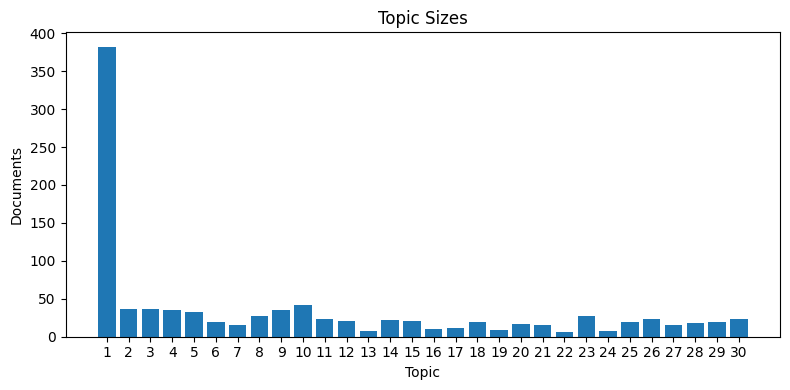

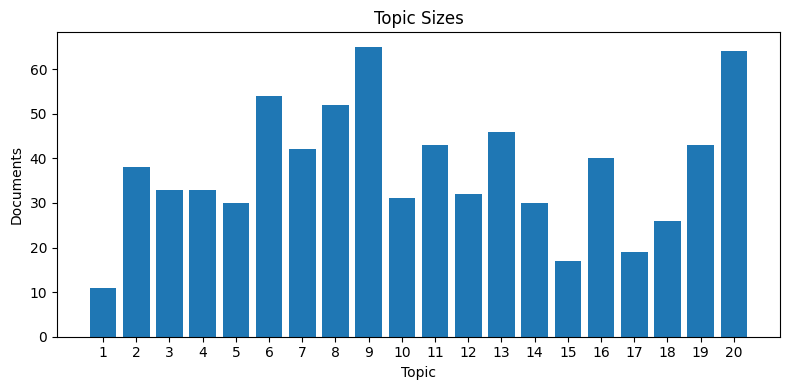

In [110]:
# Zeigt die Anzahl Dokumente pro dominantem Topic
# Erkenntnis:
# - Sind Topics ausgewogen verteilt?
# - Dominiert ein einzelnes Topic zu stark?
# - Gibt es irrelevante Mini-Topics?
plot_topic_sizes(doc_topics["en"])
plot_topic_sizes(doc_topics["de"])

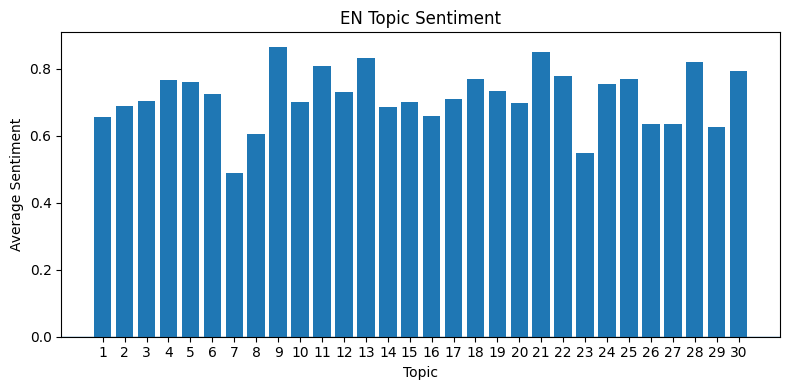

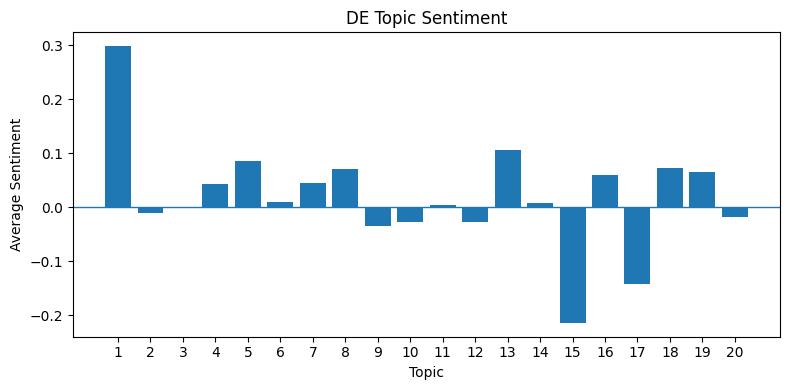

In [118]:
# Zeigt durchschnittliches Sentiment pro Topic
# Erkenntnis:
# - Welche Themen sind positiv/negativ?
# - Gibt es emotional stark geladene Topics?
# - Wie unterscheiden sich Topics semantisch/emotional?
plot_topic_sentiment(
    topic_sentiment_summary["en"],
    title="EN Topic Sentiment"
)

plot_topic_sentiment(
    topic_sentiment_summary["de"],
    title="DE Topic Sentiment"
)

In [105]:

def display_selected_model_topic_terms(selected_models, weight_col="weight_pct"):
    """
    Gibt die Top-Wörter pro Topic für manuell ausgewählte Modelle aus.
    Funktioniert mit Struktur:
    selected_models["de"]["row"]
    selected_models["en"]["row"]
    """

    for lang, selection in selected_models.items():

        row = selection["row"]
        title = selection["title"]

        score = row.get("overall_score", None)
        n_topics = row.get("n_topics", len(row["topic_terms"]))

        print(f"\n=== Ausgewähltes Topic-Modell ({lang}) ===")

        if score is not None:
            print(
                f"\n--- {title} | "
                f"Score: {score:.4f} | "
                f"Topics: {n_topics} ---"
            )
        else:
            print(
                f"\n--- {title} | "
                f"Topics: {n_topics} ---"
            )

        display(topic_terms_to_table(row, weight_col=weight_col))


def build_sentiment_df(vector_data, lang="en"):
    """
    Erstellt Sentiment-Scores je Dokument.
    Enthält doc_id für sauberen Merge mit Topic-Zuordnung.
    """

    analyzer = SentimentIntensityAnalyzer()

    documents = vector_data["documents"]
    records = []

    for doc_id, doc in enumerate(documents):
        scores = analyzer.polarity_scores(str(doc))
        compound = scores["compound"]

        pos_threshold = 0.5
        neg_threshold = -0.5

        if compound >= pos_threshold:
            label = "positive"
        elif compound <= neg_threshold:
            label = "negative"
        else:
            label = "neutral"

        records.append({
            "doc_id": doc_id,
            "document": doc,
            "sentiment_score": compound,
            "sentiment_label": label,
            "sentiment_pos": scores["pos"],
            "sentiment_neu": scores["neu"],
            "sentiment_neg": scores["neg"]
        })

    return pd.DataFrame(records)

In [98]:
def plot_topic_sentiment_from_summary(summary, method_key, lang):
    df = summary[method_key][lang]

    plot_df = df.set_index("dominant_topic")[[
        "positive", "neutral", "negative"
    ]]

    plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic + Sentiment')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_sentiment_from_summary(topic_sentiment_summary, "bow_lda", "de")

KeyError: 'bow_lda'

In [10]:
def topic_terms_to_table(row, weight_col="weight_pct"):
    return pd.DataFrame({
        topic: [
            f'{item["word"]} ({item[weight_col]:.1f}%)'
            for item in terms
        ]
        for topic, terms in row["topic_terms"].items()
    })

    return pd.DataFrame(records)
def display_top_topic_models(tuning_interpreted_by_lang, model_name, top_k=3, weight_col="weight_pct"):
    for lang, tuning_df in tuning_interpreted_by_lang.items():

        print(f"\n=== Top {top_k} {model_name} Modelle ({lang}) ===")

        for rank, (idx, row) in enumerate(tuning_df.head(top_k).iterrows(), start=1):
            print(
                f"\n--- Rang {rank} | Index {idx} | "
                f"Score: {row['overall_score']:.4f} | "
                f"Topics: {row['n_topics']} ---"
            )

            display(topic_terms_to_table(row, weight_col=weight_col))


def plot_topic_words(row, topic_id=1, top_n=10, title=None):
    topic_key = f"Topic {topic_id}"
    terms = row["topic_terms"][topic_key][:top_n]

    words = [t["word"] for t in terms][::-1]
    weights = [t["abs_weight"] for t in terms][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(words, weights)
    plt.xlabel("Weight")
    plt.title(title or f"{topic_key} - Top Words")
    plt.tight_layout()
    plt.show()
    
def plot_multiple_topics(row, topic_ids=None, top_n=10):
    topic_terms = row["topic_terms"]

    if topic_ids is None:
        topic_ids = range(1, len(topic_terms) + 1)

    for topic_id in topic_ids:
        plot_topic_words(
            row=row,
            topic_id=topic_id,
            top_n=top_n,
            title=f"Topic {topic_id}"
        )

def plot_multiple_topics(row, topic_ids=None, top_n=10):
    topic_terms = row["topic_terms"]

    if topic_ids is None:
        topic_ids = range(1, len(topic_terms) + 1)

    for topic_id in topic_ids:
        plot_topic_words(
            row=row,
            topic_id=topic_id,
            top_n=top_n,
            title=f"Topic {topic_id}"
        )

def plot_topic_term_heatmap(row, top_n=10, title="Topic-Term Heatmap"):
    topic_terms = row["topic_terms"]

    records = []

    for topic, terms in topic_terms.items():
        for term in terms[:top_n]:
            records.append({
                "topic": topic,
                "word": term["word"],
                "weight": term["abs_weight"]
            })

    df = pd.DataFrame(records)

    heatmap_data = (
        df.pivot_table(
            index="word",
            columns="topic",
            values="weight",
            fill_value=0
        )
    )

    plt.figure(figsize=(12, max(5, len(heatmap_data) * 0.25)))
    plt.imshow(heatmap_data, aspect="auto")
    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.colorbar(label="Weight")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def compute_topic_overlap_matrix(row):
    topics = {
        topic: [item["word"] for item in terms]
        for topic, terms in row["topic_terms"].items()
    }

    topic_names = list(topics.keys())
    matrix = np.zeros((len(topic_names), len(topic_names)))

    for i, topic_a in enumerate(topic_names):
        for j, topic_b in enumerate(topic_names):
            set_a = set(topics[topic_a])
            set_b = set(topics[topic_b])

            union = set_a | set_b
            intersection = set_a & set_b

            matrix[i, j] = len(intersection) / len(union) if union else 0

    return pd.DataFrame(matrix, index=topic_names, columns=topic_names)

def plot_topic_overlap_matrix(row, title="Topic Word Overlap Matrix"):
    overlap_df = compute_topic_overlap_matrix(row)

    plt.figure(figsize=(8, 6))
    plt.imshow(overlap_df, aspect="auto")
    plt.xticks(range(len(overlap_df.columns)), overlap_df.columns, rotation=90)
    plt.yticks(range(len(overlap_df.index)), overlap_df.index)
    plt.colorbar(label="Jaccard Overlap")
    plt.title(title)
    plt.tight_layout()
    plt.show()
def plot_topic_sizes(doc_topic_df, title="Topic Sizes"):
    counts = (
        doc_topic_df["dominant_topic"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Topic")
    plt.ylabel("Documents")
    plt.title(title)
    plt.tight_layout()
    plt.show()
def plot_topic_sentiment(df, title="Topic Sentiment"):

    ax = df.plot(
        x="dominant_topic",
        y="avg_sentiment",
        kind="bar",
        legend=False,
        figsize=(12, 5)
    )

    ax.set_title(title)
    ax.set_xlabel("Topic")
    ax.set_ylabel("Average Sentiment")

    plt.axhline(0, color="black", linewidth=1)

    plt.show()
